In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("india_yearly_full_release_long_format.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())

Shape: (17214, 13)
  Country Country code                State State code       State type  Year  \
0   India          IND  Andaman and Nicobar         AN  Union territory  2019   
1   India          IND  Andaman and Nicobar         AN  Union territory  2019   
2   India          IND  Andaman and Nicobar         AN  Union territory  2019   
3   India          IND  Andaman and Nicobar         AN  Union territory  2019   
4   India          IND  Andaman and Nicobar         AN  Union territory  2019   

   Category     Subcategory                               Variable Unit  \
0  Capacity  Aggregate fuel                                  Clean   MW   
1  Capacity  Aggregate fuel                                 Fossil   MW   
2  Capacity  Aggregate fuel                   Gas and Other Fossil   MW   
3  Capacity  Aggregate fuel  Hydro, Bioenergy and Other Renewables   MW   
4  Capacity  Aggregate fuel                             Renewables   MW   

   Value  YoY absolute change  YoY % change

In [38]:
df.drop_duplicates(inplace=True)

In [39]:
print(df.isnull().sum())
df['Value'] = df['Value'].fillna(df['Value'].mean())
df['YoY absolute change'] = df['YoY absolute change'].fillna(0)
df['YoY % change'] = df['YoY % change'].fillna(0)

Country                    0
Country code               0
State                      0
State code                 0
State type                 0
Year                       0
Category                   0
Subcategory                0
Variable                   0
Unit                       0
Value                    159
YoY absolute change     8555
YoY % change           11750
dtype: int64


In [40]:
df['Year'] = df['Year'].astype(int)

df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df['YoY absolute change'] = pd.to_numeric(df['YoY absolute change'], errors='coerce')
df['YoY % change'] = pd.to_numeric(df['YoY % change'], errors='coerce')

In [41]:
# Remove extra spaces
text_cols = ['Country', 'State', 'Category', 'Subcategory', 'Variable', 'Unit']

for col in text_cols:
    df[col] = df[col].str.strip()

df['Category'] = df['Category'].str.title()
df['State'] = df['State'].str.title()

In [42]:
df = df[df['Country'] == 'India']

df.drop(['Country code', 'State code'], axis=1, inplace=True)

In [43]:
print(df.head())
print(df.describe())
print(df.isnull().sum())

  Country                State       State type  Year  Category  \
0   India  Andaman And Nicobar  Union territory  2019  Capacity   
1   India  Andaman And Nicobar  Union territory  2019  Capacity   
2   India  Andaman And Nicobar  Union territory  2019  Capacity   
3   India  Andaman And Nicobar  Union territory  2019  Capacity   
4   India  Andaman And Nicobar  Union territory  2019  Capacity   

      Subcategory                               Variable Unit  Value  \
0  Aggregate fuel                                  Clean   MW  17.44   
1  Aggregate fuel                                 Fossil   MW  40.05   
2  Aggregate fuel                   Gas and Other Fossil   MW  40.05   
3  Aggregate fuel  Hydro, Bioenergy and Other Renewables   MW   5.25   
4  Aggregate fuel                             Renewables   MW  17.44   

   YoY absolute change  YoY % change  
0                  0.0           0.0  
1                  0.0           0.0  
2                  0.0           0.0  
3       

In [44]:
energy_df = df[df['Unit'] == 'GWh']
emission_df = df[df['Unit'] == 'ktCO2']
capacity_df = df[df['Unit'] == 'MW']

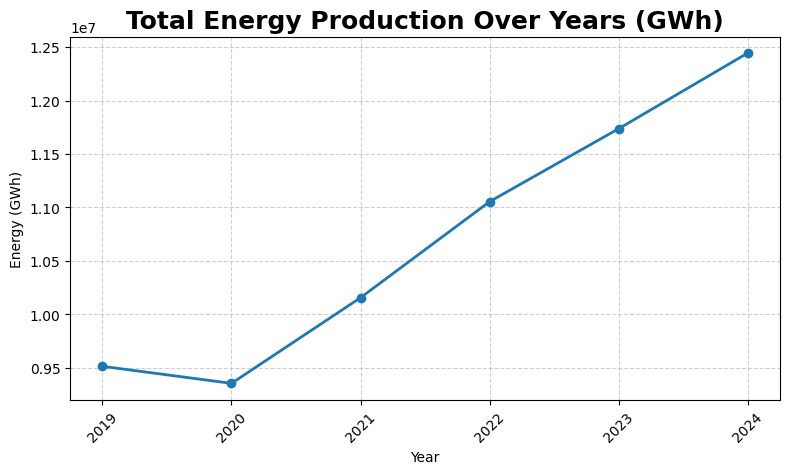

In [45]:
trend = energy_df.groupby('Year')['Value'].sum()

plt.figure(figsize=(8,5))
trend.plot(marker='o', linewidth=2)

plt.title("Total Energy Production Over Years (GWh)", fontsize=18, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Energy (GWh)")

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [46]:
df.Category.unique()

array(['Capacity', 'Electricity Generation', 'Power Sector Emissions'],
      dtype=object)

In [47]:
df.Subcategory.unique()

array(['Aggregate fuel', 'Fuel', 'Total', 'CO2 intensity'], dtype=object)

In [48]:
df.head()

,Country,State,State type,Year,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,India,Andaman And Nicobar,Union territory,2019,Capacity,Aggregate fuel,Clean,MW,17.44,0.0,0.0
1,India,Andaman And Nicobar,Union territory,2019,Capacity,Aggregate fuel,Fossil,MW,40.05,0.0,0.0
2,India,Andaman And Nicobar,Union territory,2019,Capacity,Aggregate fuel,Gas and Other Fossil,MW,40.05,0.0,0.0
3,India,Andaman And Nicobar,Union territory,2019,Capacity,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",MW,5.25,0.0,0.0
4,India,Andaman And Nicobar,Union territory,2019,Capacity,Aggregate fuel,Renewables,MW,17.44,0.0,0.0


State
Maharashtra       921862.57
Uttar Pradesh     895578.87
Madhya Pradesh    883363.69
Chhattisgarh      861358.51
Gujarat           713259.36
Name: Value, dtype: float64


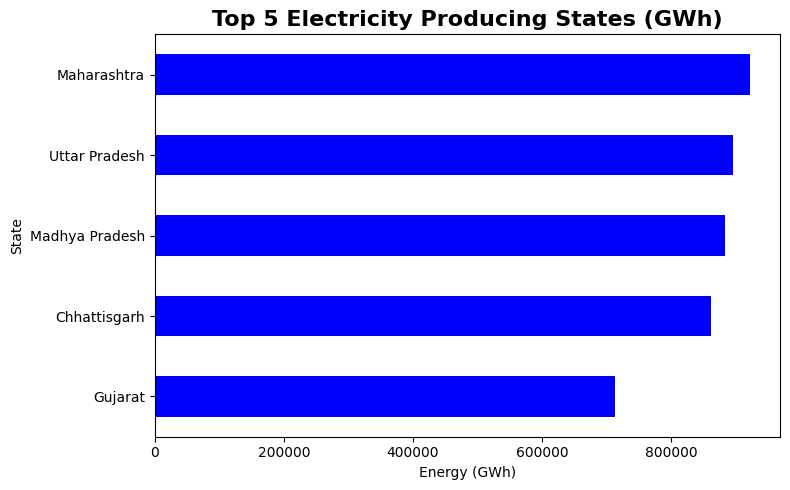

In [49]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
energy_df = df[
    (df['Category'] == 'Electricity Generation') &
    (df['Subcategory'] == 'Fuel') &
    (df['Unit'] == 'GWh') &
    (df['Country'] == 'India')
]
energy_df = energy_df[energy_df['State'] != 'India Total']
state_data = (
    energy_df
    .groupby('State')['Value']
    .sum()
    .sort_values(ascending=False)
)

top_states = state_data.head(5)
print(top_states)

plt.figure(figsize=(8,5))
top_states.sort_values().plot(kind='barh', color='blue')

plt.title("Top 5 Electricity Producing States (GWh)", fontsize=16, fontweight='bold')
plt.xlabel("Energy (GWh)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

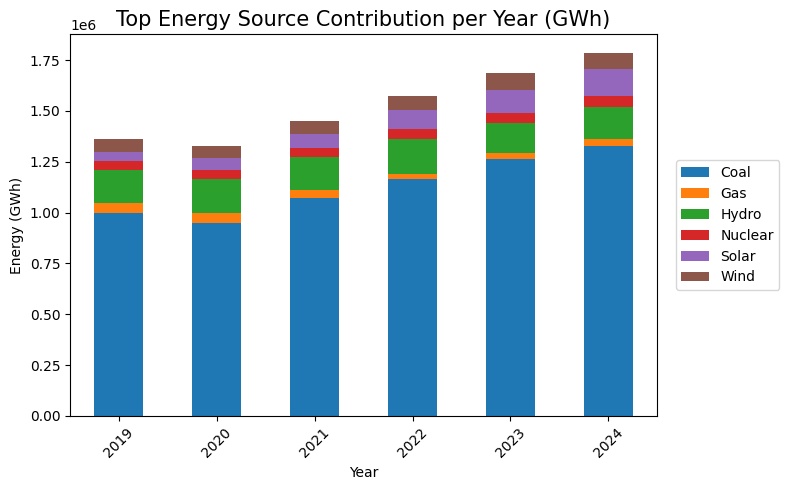

In [50]:
top_vars = energy_df.groupby('Variable')['Value'].sum().nlargest(6).index
filtered = energy_df[energy_df['Variable'].isin(top_vars)]

pivot_var = filtered.pivot_table(values='Value', index='Year', columns='Variable', aggfunc='sum')

fig, ax = plt.subplots(figsize=(8,5))   

pivot_var.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.5
)

plt.title("Top Energy Source Contribution per Year (GWh)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Energy (GWh)")

plt.xticks(rotation=45)

plt.legend(bbox_to_anchor=(1.02,0.5), loc='center left')
plt.tight_layout()
plt.show()

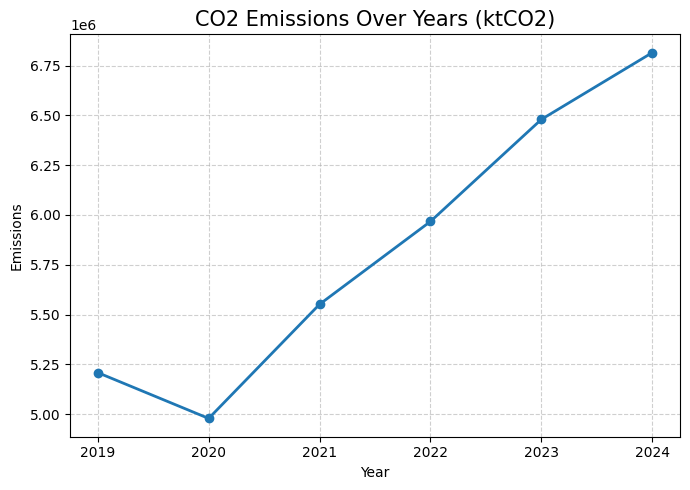

In [51]:
em_trend = emission_df.groupby('Year')['Value'].sum()

plt.figure(figsize=(7,5))
em_trend.plot(marker='o', linewidth=2)

plt.title("CO2 Emissions Over Years (ktCO2)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

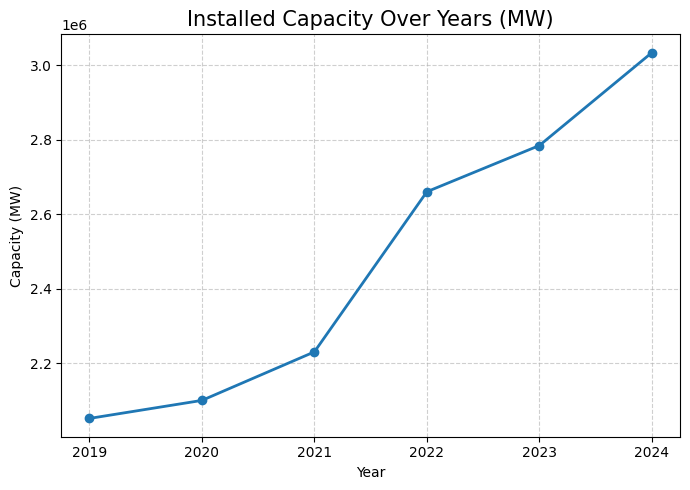

In [52]:
cap_trend = capacity_df.groupby('Year')['Value'].sum()

plt.figure(figsize=(7,5))
cap_trend.plot(marker='o', linewidth=2)

plt.title("Installed Capacity Over Years (MW)", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Capacity (MW)")

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

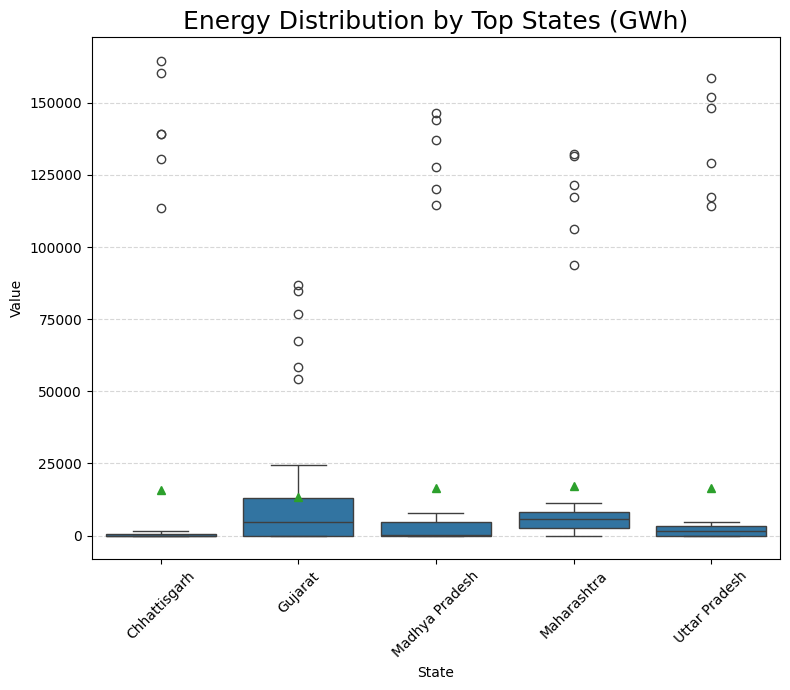

In [53]:
top_states = energy_df.groupby('State')['Value'].sum().nlargest(5).index
filtered = energy_df[energy_df['State'].isin(top_states)]

plt.figure(figsize=(8,7))

sns.boxplot(
    x='State',
    y='Value',
    data=filtered,
    showmeans=True
)

plt.title("Energy Distribution by Top States (GWh)", fontsize=18)
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

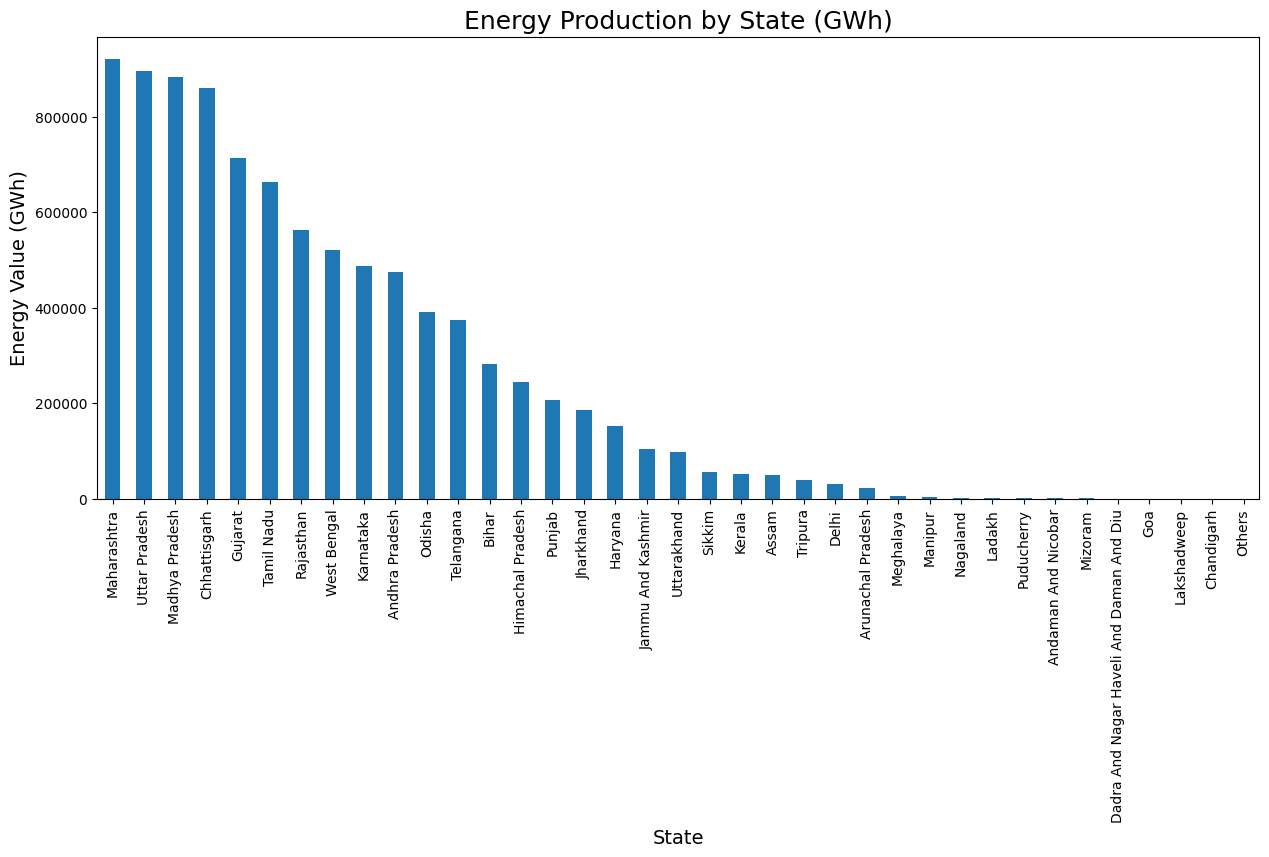

In [54]:
state_data = energy_df.groupby('State')['Value'].sum().sort_values(ascending=False)

plt.figure(figsize=(15, 6))

state_data.plot(kind='bar')

plt.title("Energy Production by State (GWh)", fontsize=18)
plt.xlabel("State", fontsize=14)
plt.ylabel("Energy Value (GWh)", fontsize=14)

plt.xticks(rotation=90)

plt.show()

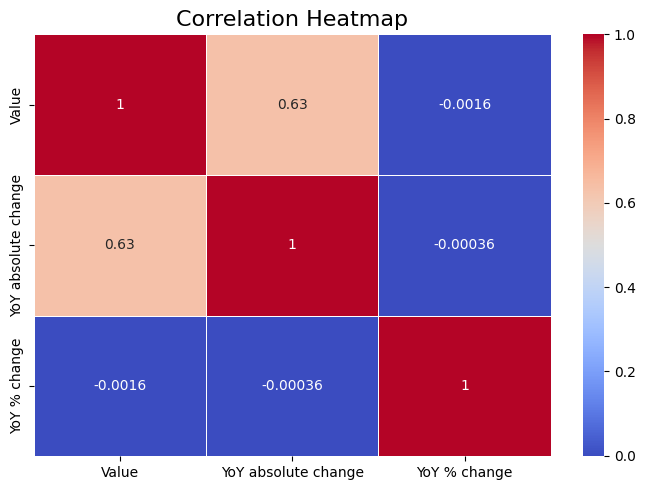

In [55]:
import seaborn as sns

corr = df[['Value', 'YoY absolute change', 'YoY % change']].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

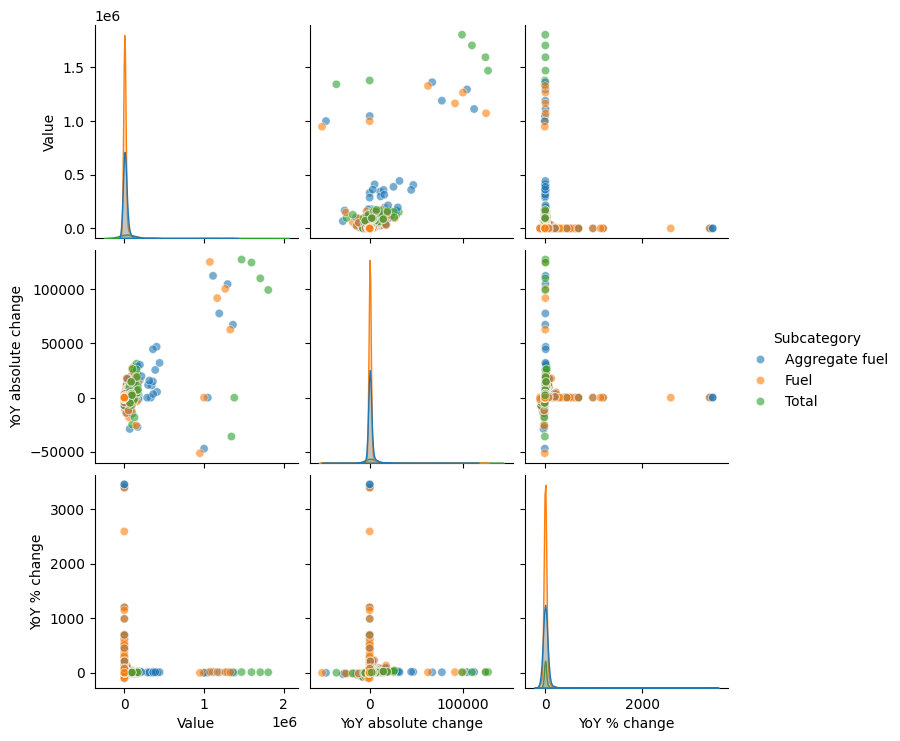

In [56]:
energy_df = df[df['Unit'] == 'GWh']
clean_df = energy_df[energy_df['YoY % change'] < 5000]

sns.pairplot(
    clean_df,
    vars=['Value', 'YoY absolute change', 'YoY % change'],
    hue='Subcategory',
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)

plt.show()

    Variable        Value    Percent
1       Coal  13554166.93  73.009222
3      Hydro   1928234.48  10.386393
5      Solar   1031243.54   5.554771
6       Wind    851063.36   4.584234
4    Nuclear    565594.18   3.046561
2        Gas    456038.20   2.456440
0  Bioenergy    178665.99   0.962380


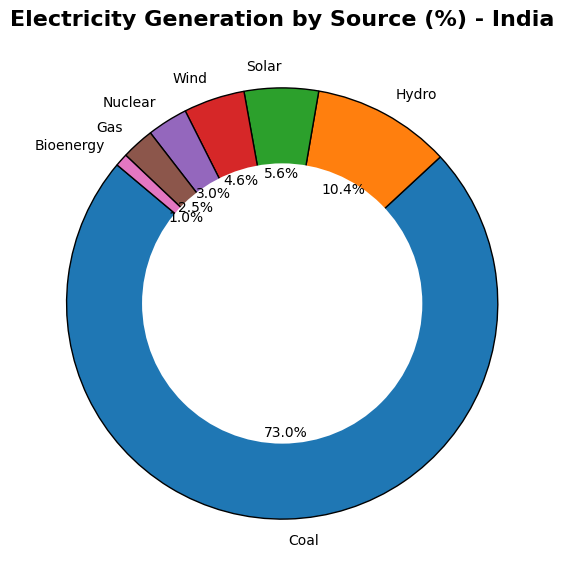

In [57]:
energy_df = df[
    (df['Category'] == 'Electricity Generation') &
    (df['Subcategory'] == 'Fuel') &
    (df['Unit'] == 'GWh')
]

valid_sources = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind', 'Bioenergy', 'Nuclear']
energy_df = energy_df[energy_df['Variable'].isin(valid_sources)]

var_data = energy_df.groupby('Variable', as_index=False)['Value'].sum()

var_data['Percent'] = (var_data['Value'] / var_data['Value'].sum()) * 100
var_data = var_data.sort_values(by='Percent', ascending=False)

print(var_data)

plt.figure(figsize=(8,7))

plt.pie(
    var_data['Percent'],
    labels=var_data['Variable'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'black'}
)

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Electricity Generation by Source (%) - India",
          fontsize=16, fontweight='bold')

plt.show()

In [58]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
print(df['Unit'].unique())

['MW' '%' 'GWh' 'ktCO2' 'gCO2/kWh']


In [60]:
df = df[df['Unit'] == 'GWh']

df.head()

,Country,State,State type,Year,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
21,India,Andaman And Nicobar,Union territory,2019,Electricity Generation,Aggregate fuel,Clean,GWh,21.73,0.0,0.0
22,India,Andaman And Nicobar,Union territory,2019,Electricity Generation,Aggregate fuel,Fossil,GWh,88.62,0.0,0.0
23,India,Andaman And Nicobar,Union territory,2019,Electricity Generation,Aggregate fuel,Gas and Other Fossil,GWh,88.62,0.0,0.0
24,India,Andaman And Nicobar,Union territory,2019,Electricity Generation,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",GWh,7.55,0.0,0.0
25,India,Andaman And Nicobar,Union territory,2019,Electricity Generation,Aggregate fuel,Renewables,GWh,21.73,0.0,0.0


In [61]:
df = df[['Year', 'Variable', 'Value']]

df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

df = df.dropna()

df.head()

,Year,Variable,Value
21,2019,Clean,21.73
22,2019,Fossil,88.62
23,2019,Gas and Other Fossil,88.62
24,2019,"Hydro, Bioenergy and Other Renewables",7.55
25,2019,Renewables,21.73


In [62]:
df = df.groupby(['Year', 'Variable'])['Value'].sum().reset_index()

df.head()

,Year,Variable,Value
0,2019,Bioenergy,29493.53
1,2019,Clean,663181.42
2,2019,Coal,1997670.48
3,2019,Fossil,2093838.25
4,2019,Gas,95960.78


In [63]:
df = pd.get_dummies(df, columns=['Variable'], drop_first=True)

In [64]:
X = df.drop('Value', axis=1)
y = df['Value']

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [67]:
y_pred = model.predict(X_test)

In [68]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MSE: 24354274769.126453
R²: 0.962926070352964


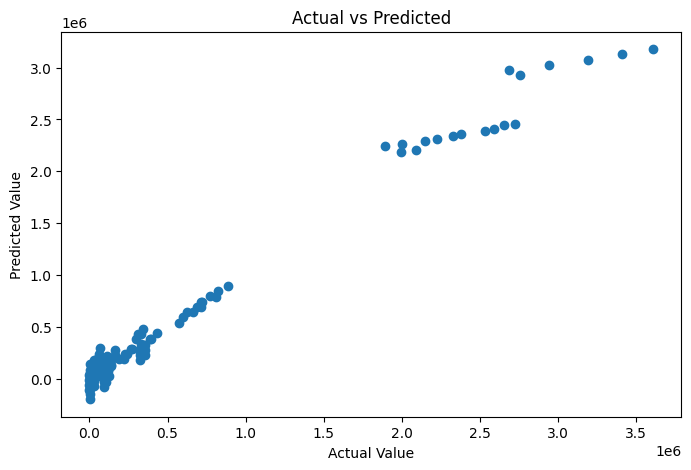

In [69]:
y_pred = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(y, y_pred)

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted")

plt.show()

In [70]:
print(X.columns)

Index(['Year', 'Variable_Clean', 'Variable_Coal', 'Variable_Fossil',
       'Variable_Gas', 'Variable_Gas and Other Fossil', 'Variable_Hydro',
       'Variable_Hydro, Bioenergy and Other Renewables', 'Variable_Nuclear',
       'Variable_Other Fossil', 'Variable_Other Renewables',
       'Variable_Renewables', 'Variable_Solar', 'Variable_Total Generation',
       'Variable_Wind', 'Variable_Wind and Solar'],
      dtype='object')


In [71]:
year = int(input("Enter Year: "))
variable = input("Enter Variable: ")

new_data = pd.DataFrame([[0]*len(X.columns)], columns=X.columns)

new_data['Year'] = year
new_data[f"Variable_{variable}"] = 1

prediction = model.predict(new_data)

print("Predicted Energy (GWh):", prediction[0])

ValueError: invalid literal for int() with base 10: ''